In [83]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score

In [2]:
print(torch.__version__)
print(torchvision.__version__)

2.12.1+cpu
0.27.1+cpu


In [3]:
train_data=datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data=datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

100%|██████████████████████████████████████████████████████████████████████████████████████████| 26.4M/26.4M [00:08<00:00, 3.12MB/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 163kB/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████| 4.42M/4.42M [00:01<00:00, 2.45MB/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 2.92MB/s]


In [6]:
image,label=train_data[0]
image.shape,label

(torch.Size([1, 28, 28]), 9)

In [14]:
len(train_data),len(test_data)

(60000, 10000)

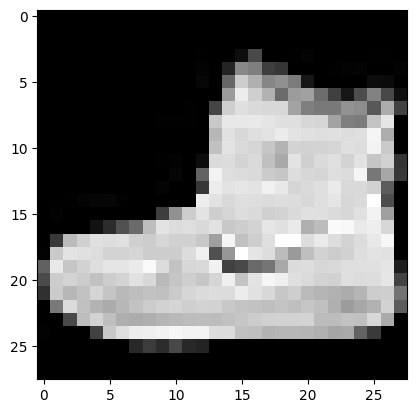

In [21]:
image,label=train_data[0]
plt.imshow(image.squeeze(),cmap='gray')

In [40]:
class_names=train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

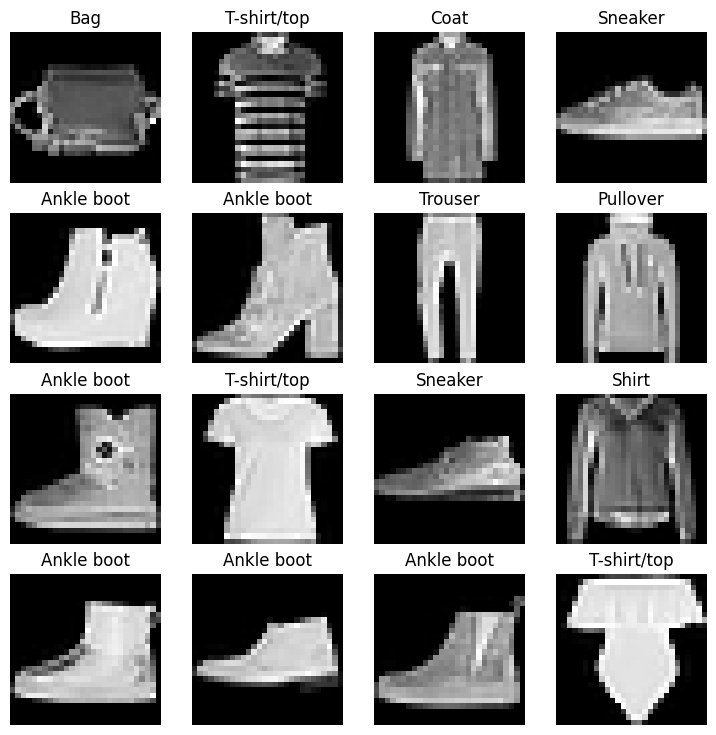

In [47]:
row,col=4,4
fig = plt.figure(figsize=(9, 9))
for i in range(1,row*col+1):
    index=torch.randint(0,len(train_data),(1,)).item()
    fig.add_subplot(row,col,i)
    img,label=train_data[index]
    plt.imshow(img.squeeze(),cmap='gray')
    plt.title(class_names[label])
    plt.axis(False)

In [48]:
train_data,test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [50]:
train_data_loader=DataLoader(train_data,batch_size=32,shuffle=True)
test_data_loader=DataLoader(test_data,batch_size=32,shuffle=False)

In [51]:
train_data_loader,test_data_loader

(<torch.utils.data.dataloader.DataLoader at 0x20c10988980>,
 <torch.utils.data.dataloader.DataLoader at 0x20c15668e10>)

In [55]:
train_data_features,train_data_label=next(iter(train_data_loader))
train_data_features.shape,train_data_label.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

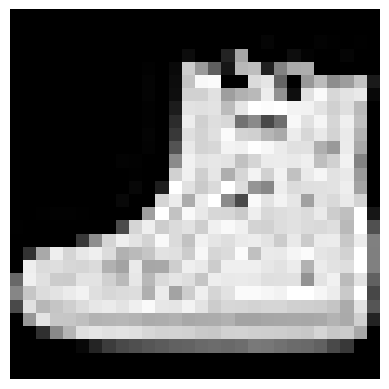

In [64]:
idx=torch.randint(0,len(train_data_features),(1,)).item()
img=train_data_features[idx]
plt.imshow(img.squeeze(),cmap='grey')
plt.axis(False)

In [76]:
class FashionMNIST_Classifier(nn.Module):
    def __init__(self,input_size,output_shape,hidden_layer):
        super().__init__()

        self.layerstack=nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_size,out_features=hidden_layer),
            nn.Linear(in_features=hidden_layer,out_features=output_shape)
        )

    def forward(self,x):
        return self.layerstack(x)

In [77]:
model1=FashionMNIST_Classifier(784,len(class_names),8)
model1

FashionMNIST_Classifier(
  (layerstack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=10, bias=True)
  )
)

In [78]:
loss_func=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(model1.parameters(),lr=0.1)

In [79]:
from timeit import default_timer as timer
def time(start,end):
    print(f"Time taken to train is {end-start}")

In [82]:
torch.manual_seed(18)
start_time=timer()
epochs=3
for epoch in tqdm(range(epochs)):
    training_loss=0
    print(f"Epoch number {epoch}:")
    for batch,(x_train,y_train) in enumerate(train_data_loader):
        model1.train()
        y_logit=model1(x_train)
        loss=loss_func(y_logit,y_train)
        training_loss+=loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch%400==0:
            print(f"Looked at {batch*len(x_train)}/{len(train_data_loader.dataset)} samples")

    training_loss/=len(train_data_loader)
    print(f"Training loss for epoch {epoch} is {training_loss}")
end_time=timer()
time(start_time,end_time)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch number 0:
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Training loss for epoch 0 is 0.45962077379226685
Epoch number 1:
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Training loss for epoch 1 is 0.44777438044548035
Epoch number 2:
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Training loss for epoch 2 is 0.44026800990104675
Time taken to train is 51.00923349999357


In [86]:
model1.eval()
with torch.inference_mode():
    testing_loss,testing_accuracy=0,0
    for x_test,y_test in test_data_loader:
        y_test_logit=model1(x_test)
        y_test_pred=y_test_logit.argmax(dim=1)
        loss=loss_func(y_test_logit,y_test)
        testing_loss+=loss
        testing_accuracy+=accuracy_score(y_test,y_test_pred)
    testing_loss/=len(test_data_loader)
    testing_accuracy/=len(test_data_loader)
    print(f"Testing loss:{testing_loss}")
    print(f"Testing accuracy:{testing_accuracy}")

Testing loss:0.48023051023483276
Testing accuracy:0.8287739616613419
